# **Pulse Shape Discrimination**

The primary objective of this project is to develop a binary classifier capable of discriminating between electrical signals generated by **neutrons** and **photons** within a scintillator detector. The waveforms produced by these two particles are remarkably similar, differing primarily in subtle variations within the pulse tail. The project implements and directly compares two different methodologies: a Deep Learning approach using a **Convolutional Neural Network (CNN)** and a traditional Machine Learning algorithm, specifically a **Random Forest classifier**.

To accurately assign the ground-truth labels required to train the models, an independent dataset of **Time of Flight (ToF)** measurements, acquired by an adjacent detector, is utilized. Due to the significant difference in mass and velocity, the ToF distributions for photons and neutrons are clearly distinct. By applying specific cuts to the ToF spectrum, it is possible to label the corresponding scintillator signals with high precision. This rigorously labeled dataset is then used to train both the CNN and the RandomForest for the classification task.

Beyond the initial model construction, the project is structured around a comprehensive comparative analysis to identify the most effective optimization strategy.
Firstly, it investigates the impact of scaling the CNN's architectural complexity versus the benefits of dataset purification, demonstrating how applying stricter cuts to the ToF spectrum affects the overall accuracy.
Secondly, by benchmarking the DL architectures against the Random Forest classifier, the study evaluates whether the computational cost of a CNN is justified or comparable with traditional ML.

In [1]:
import numpy as np
import sklearn
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
import os
if not os.path.exists("data_small.npy"):
    !gdown https://drive.google.com/uc?id=1vbydwF65iFsPQjWeqUYbtWQ7Whjfn40v

In [6]:
data_raw = np.load('data_small.npy')

The initial phase of the analysis focuses on inspecting and formatting the raw dataset, comprising 55686 one-dimensional arrays. Each raw array has as the first entry the detector identifier (can be ignored), and the second entry stores the corresponding Time of Flight (ToF) in nanoseconds.

To isolate the actual electrical signal required for the Pulse Shape Discrimination, the first two entries are removed and stored separately. This preprocessing step yields a clean waveform dataset composed of 55686 arrays, each containing 512 elements representing the pure electrical pulse shape. Since the pulse is sampled at a rate of 1 GHz, the 512 numbers represent 512 ns of the pulse shape.

In [7]:
print(data_raw[0].shape)
print(data_raw.shape)

(514,)
(55686, 514)


[   2.     100.905   -7.      -6.      -8.      -9.      -9.      -7.
   -9.      -8.      -8.      -5.      -8.      -8.     -11.      -8.
   -8.      -8.      -8.      -8.      -8.      -9.      -8.      -8.
   -8.      -6.      -7.      -8.      -7.      -7.     -10.      -7.
   -8.      -7.      -7.      -5.      -8.      -6.     -10.      -7.
   -8.      -8.      -8.      -7.      -7.      -5.     -10.      -8.
   -8.      -7.      -9.      -7.      -5.      -7.      -8.      -8.
   -7.      -6.      -5.      -4.     -10.     -10.      -7.      -9.
   -6.      -6.      -5.      -9.     -11.      -9.      -8.      -5.
   -6.      -8.     -10.      -9.      -6.      -5.      -5.     -10.
   -6.      -8.      -9.      -6.      -7.      -7.      -9.     -10.
   -9.      -6.      -8.      -6.     -10.      -8.      -8.      -6.
   -7.      -5.      -7.      -7.      -7.      -8.      -9.      -6.
   -7.      -9.      -8.      -8.      -7.      -9.      -8.      -6.
   -6.     -10.     

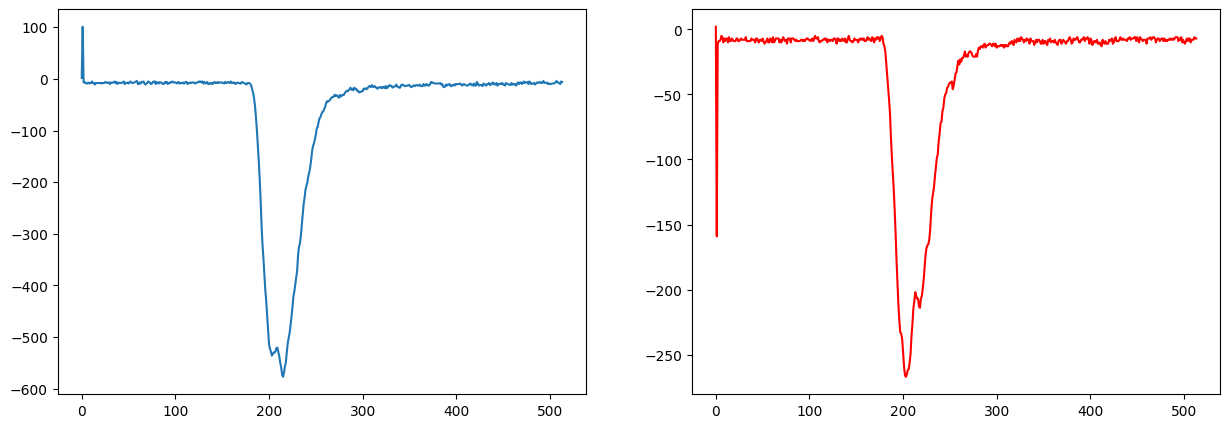

In [8]:
print(data_raw[0])
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(data_raw[0])
axs[1].plot(data_raw[1], 'r')

plt.show()


(55686, 512)


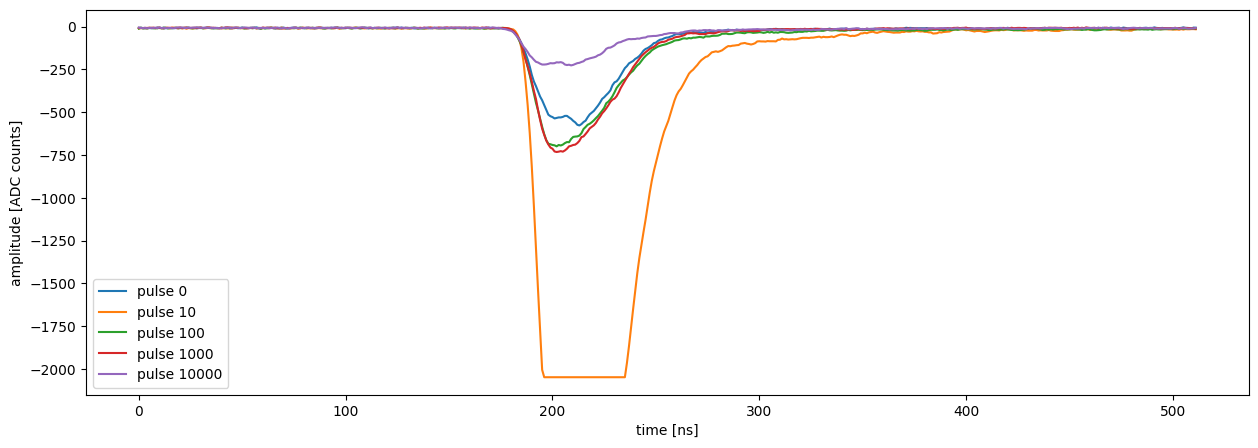

In [9]:
pulses = data_raw[:, 2:]

print(pulses.shape)

fig, ax = plt.subplots(figsize=(15,5))
ax.plot(pulses[0], label = "pulse 0")
ax.plot(pulses[10], label = "pulse 10")
ax.plot(pulses[100], label = "pulse 100")
ax.plot(pulses[1000], label = "pulse 1000")
ax.plot(pulses[10000], label = "pulse 10000")
ax.set_xlabel("time [ns]")
ax.set_ylabel("amplitude [ADC counts]")
plt.legend()
fig.show()

To give the labels to the different signals, let's use the ToF measurement (`tof`). Let's firstly plot how the tof measurement of photons and neutrons differ.

(55686,)
-371.822
287.852


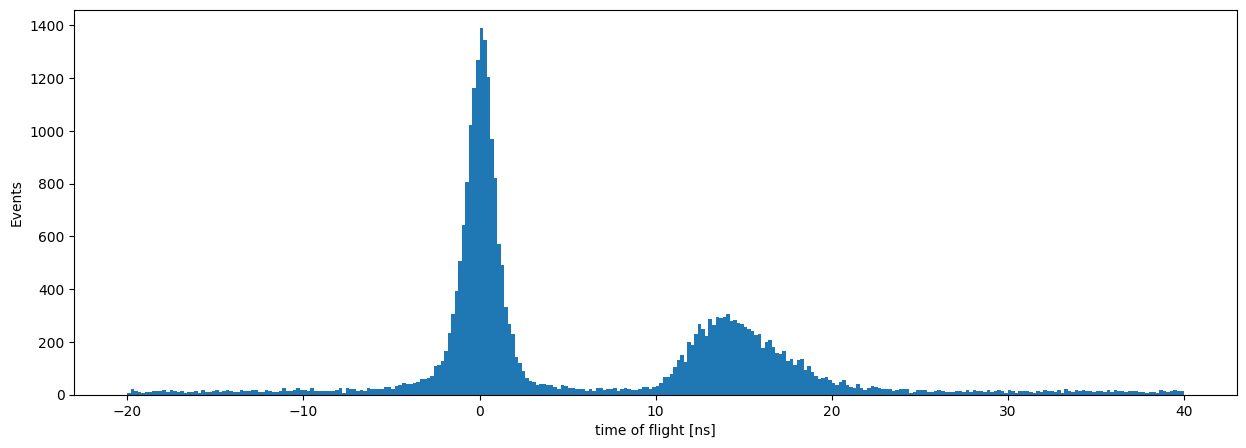

In [10]:
tof = data_raw[:, 1]
print(tof.shape)
print(tof.min()) # there are some negative tof measurements, that are not a problem because they could be bkg random coinciences, or fluctuations.
print(tof.max())

fig, ax = plt.subplots(figsize=(15,5))
ax.hist(tof, bins=300, range=(-20, 40))  #5 bin per ns; let's reduce th range on the x axis in order to isolate the signal from photons and neutrons.
ax.set_xlabel("time of flight [ns]")
ax.set_ylabel("Events")
fig.show()

Ground-truth labeling is performed by exploiting the extracted Time of Flight (ToF) measurements. Initially, the ToF distribution is plotted to show the clear physical separation between photon and neutron arrival times.

Based on this distribution, empirical cuts are applied to the ToF spectrum. These thresholds allow for the precise assignment of labels to the corresponding waveforms. By selecting strict cutoff values, it is possible to filter out overlapping or ambiguous signals, thereby guaranteeing the high purity of the final dataset required to train the classification algorithms.

In [11]:
photons_data = data_raw[(tof >= -6) & (tof <= 6)]
neutrons_data = data_raw[(tof >= 9) & (tof <= 22)]

photons_pulses = photons_data[:, 2:]
neutrons_pulses = neutrons_data[:, 2:]

print('Gammas: ', photons_pulses.shape)
print('Neutrons: ', neutrons_pulses.shape)



Gammas:  (16108, 512)
Neutrons:  (9181, 512)


With the photon and neutron pulse arrays successfully isolated based on the ToF cuts, the next phase involves formatting the data.   
Let's start from the **CNN**. Initially, the two arrays are concatenated into a single dataset (`data`), and binary labels are explicitly assigned: 0 for neutrons and 1 for photons (`labels`) .  
Subsequently, the signals undergo amplitude normalization to ensure the CNN focuses strictly on the pulse shape rather than absolute intensity. The dataset is then reshaped to add the channel dimension, adapting it to the 3D tensor format (number_of_signals, length, channels) expected by a Conv1D layer. Finally, a shuffling operation is applied to the data and labels to prevent sequential bias during the training phase.


In [12]:
data = np.vstack((photons_pulses, neutrons_pulses))
labels = np.zeros(len(data), dtype=int) # default 0 for all (so neutrons)
labels[:len(photons_pulses)] = 1 # impose 1 (16108 photons)

# 0 = neutrons
# 1 = photons

data = data / (-data.min(axis=1, keepdims=True)) #normalization. The signals are negative, so the '-' is to make them positive.

data = np.reshape(data, (-1, data.shape[1], 1)) #reshape

print('Data: ', data.shape)

np.random.seed(42)
shuffle_indices = np.arange(0, len(data), dtype=int)
np.random.shuffle(shuffle_indices)
data = data[shuffle_indices]
labels = labels[shuffle_indices]

Data:  (25289, 512, 1)


In [13]:
from sklearn.model_selection import train_test_split

data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.2, random_state=42)

data_train, data_val, labels_train, labels_val = train_test_split(data_train, labels_train, test_size=0.2, random_state=42)

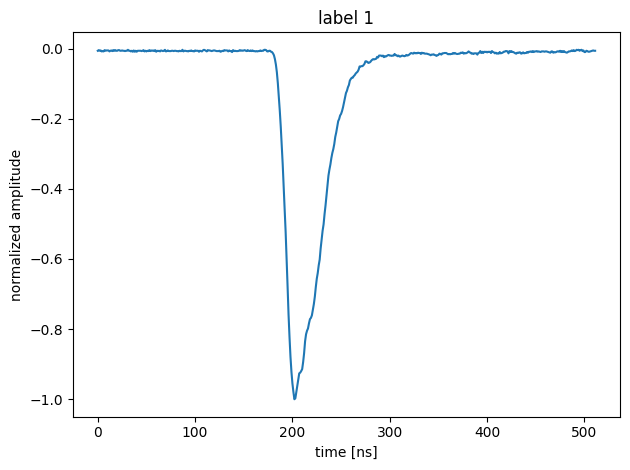

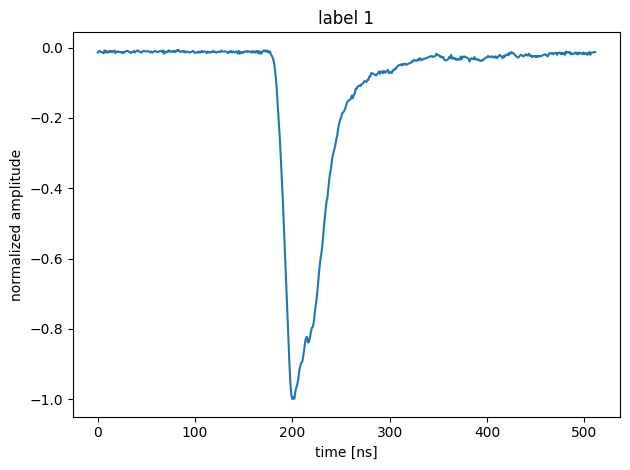

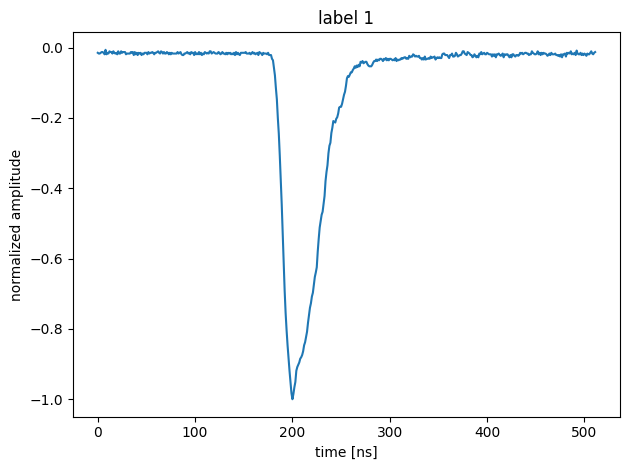

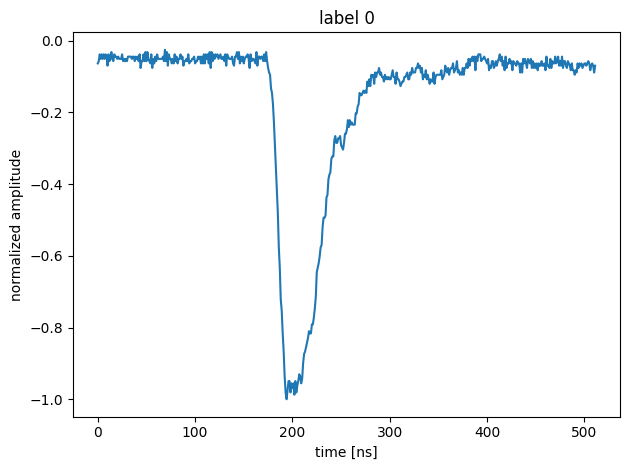

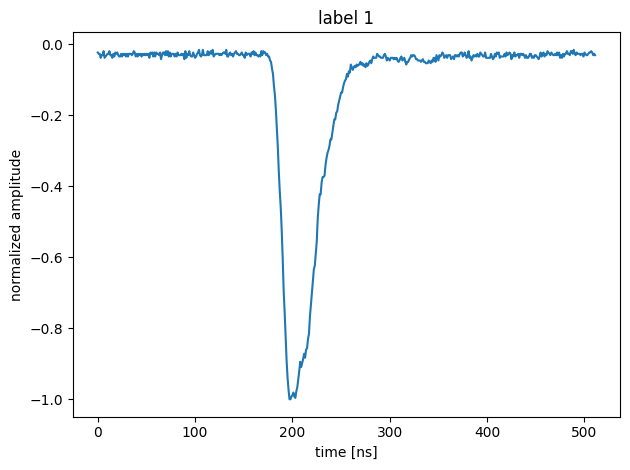

In [14]:
# plot a few events
for i in range(5):
    fig, ax = plt.subplots(1, 1)
    ax.plot(data_train[i,:,0])
    ax.set_title(f"label {labels_train[i]}")
    ax.set_xlabel("time [ns]")
    ax.set_ylabel("normalized amplitude")
    fig.tight_layout()
    plt.show()
    plt.close("all")

## **Simple CNN**


The architecture chosen for the first CNN is simple and it's the following:

- Input signals of shape (512, 1);
- 1D Convolutional layer with 16 filters;
- 1D Max Pooling layer;
- Flatten layer;
- Dense output layer with 1 neuron.

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, Dropout

model = Sequential()

model.add(Input(shape=(512, 1)))
model.add(Conv1D(16, kernel_size=5, padding="same", activation='relu'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 512, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,193 (16.38 KB)

 Trainable params: 4,193 (16.38 KB)

 Non-trainable params: 0 (0.00 B)

Now let's train the network and estimate the accuracy. The implementation choices are:
- **Compilation**: The **Adam** optimizer is utilized for efficient weight updating. Since this is a two-class classification problem, the designated loss function is **Binary Crossentropy**. The model's performance is monitored using the **Accuracy** metric.
- **Early stopping**: By setting the parameter `patience=5`, the training will automatically stop if the error on the validation set (`val_loss`) fails to show improvement for 5 consecutive epochs. Coupled with `restore_best_weights=True`, it ensures the model always retains the optimal parameters from the best epoch, neutralizing any subsequent overfitting.
- **Training**: The algorithm is trained for a maximum of 13 **epochs**, processing the signals in batches of 64 (batch_size=64).

In [17]:
%%time
import tensorflow as tf
from tensorflow import keras

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose = 2, restore_best_weights=True)

history = model.fit(data_train, labels_train,
                    validation_data=(data_val, labels_val),
                    epochs=13,
                    batch_size=64,
                    callbacks = callbacks)

Epoch 1/13


2026-08-14 15:41:24.056716: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 33144832 exceeds 10% of free system memory.


506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9015 - loss: 0.2831 - val_accuracy: 0.9587 - val_loss: 0.1804
Epoch 2/13
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9593 - loss: 0.1812 - val_accuracy: 0.9575 - val_loss: 0.1723
Epoch 3/13
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9594 - loss: 0.1801 - val_accuracy: 0.9573 - val_loss: 0.1798
Epoch 4/13
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9594 - loss: 0.1773 - val_accuracy: 0.9585 - val_loss: 0.1712
Epoch 5/13
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9594 - loss: 0.1770 - val_accuracy: 0.9565 - val_loss: 0.1850
Epoch 6/13
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9595 - loss: 0.1765 - val_accuracy: 0.9582 - val_loss: 0.1711
Epoch 7/13
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9595 - loss: 0.1750 - val_accuracy: 0.9573 - val_loss: 0.1937
Epoch 8/13
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9593 - loss: 0.1756 - val_accuracy: 0.9570 - val_

In [18]:
test_loss, test_accuracy = model.evaluate(data_test, labels_test, verbose=1)
print('Test loss: ', test_loss)
print('Test accuracy: ', test_accuracy * 100, '%')

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9585 - loss: 0.1830
Test loss:  0.18300050497055054
Test accuracy:  95.84816098213196 %


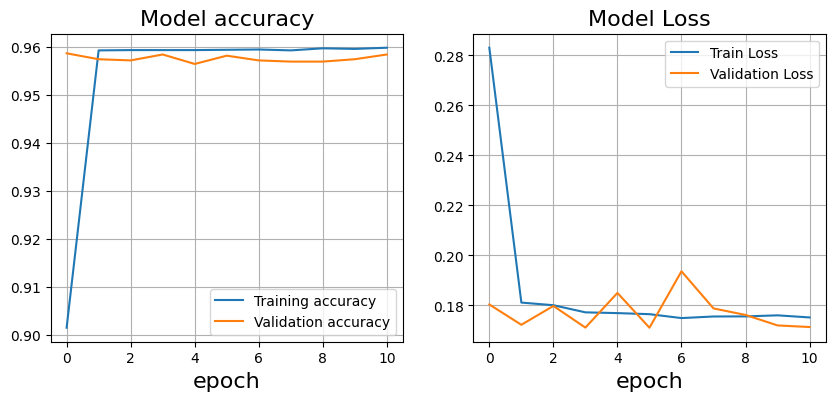

In [19]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")
plt.title('Model accuracy', fontsize=16)
plt.xlabel('epoch', fontsize=16)
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=16)
plt.xlabel('epoch', fontsize=16)
plt.grid(True)
plt.legend()
plt.show()


159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


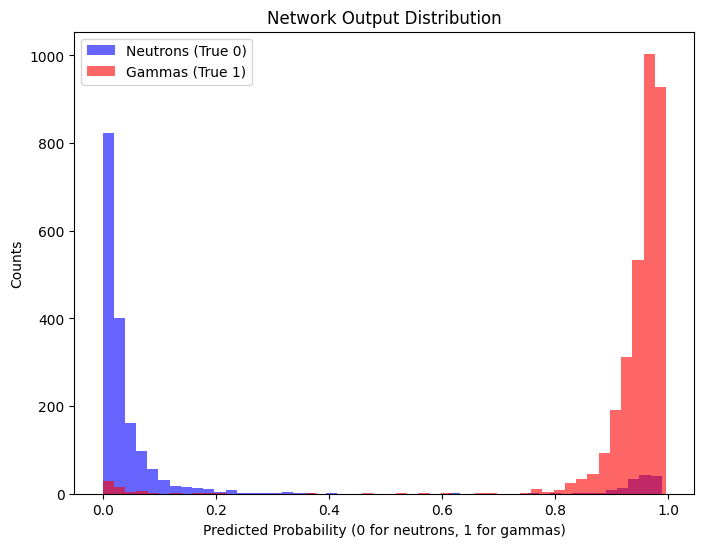

In [20]:
preds = model.predict(data_test).flatten() #predicitons of the model on teh test set.
# gives an array with the probabilities

plt.figure(figsize=(8,6))

plt.hist(preds[labels_test == 0], bins=50, alpha=0.6, color='blue', label='Neutrons (True 0)')
plt.hist(preds[labels_test == 1], bins=50, alpha=0.6, color='red', label='Gammas (True 1)')

plt.title("Network Output Distribution")
plt.xlabel("Predicted Probability (0 for neutrons, 1 for gammas)")
plt.ylabel("Counts")
plt.legend()
plt.show()

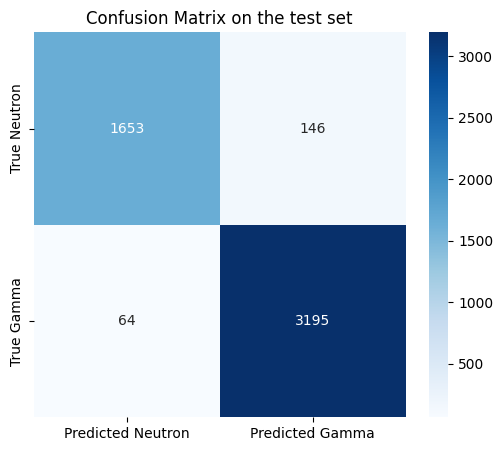

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds_binary = (preds > 0.5).astype(int) #50 % threshold: photons > 0.5, neutrons < 0.5.
# is the predictions array, but with just 1 or 0, not the continuous probabilities

cm = confusion_matrix(labels_test, preds_binary)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Neutron', 'Predicted Gamma'],
            yticklabels=['True Neutron', 'True Gamma'])
plt.title("Confusion Matrix on the test set")
plt.show()

For a more comprehensive evaluation, the **Precision**, **Recall**, **F1 Score**, and **ROC AUC** metrics were computed. In this binary classification framework, neutrons are defined as the negative class (Class 0) and photons as the positive class (Class 1). Consequently, these metrics specifically assess the algorithm's capability to correctly isolate and classify photon signals:
- **Precision**: represents the fraction of true photons among all the signals that the model classified as photons. A high precision indicates a strong ability to minimize False Positives, meaning the algorithm rarely misclassifies a background neutron as a photon.
- **Recall**: represents the proportion of actual photons present in the dataset that were successfully identified by the network. A high recall implies a strong ability to minimize False Negatives, ensuring that very few true photon signals are missed or erroneously assigned to the neutron class.
- **F1 Score**: serves as a crucial indicator to evaluate the balance between precision and recall. A high F1 Score demonstrates that the classifier has achieved an optimal equilibrium, successfully maximizing true photon detection without polluting the selection with neutron contamination.
- **ROC AUC (Area Under the Curve)**: measures the algorithm's overall ability to discriminate between the two classes across all possible classification thresholds. A high AUC value (approaching 1.0) indicates that the model is intrinsically highly capable of distinguishing photons from neutrons.

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

prec = precision_score(labels_test, preds_binary)
recall = recall_score(labels_test, preds_binary)
f1 = f1_score(labels_test, preds_binary)
auc = roc_auc_score(labels_test, preds)

print("Precision:", prec)
print("Recall:", recall)
print("F1 score:", f1)
print(f"Area under the ROC curve (AUC): {auc:.4f}")

Precision: 0.9563005088296918
Recall: 0.9803620742559067
F1 score: 0.9681818181818181
Area under the ROC curve (AUC): 0.9564


The first network yielded a test accuracy of ~**95.8%**, which is relatively low for this type of physical discrimination. Moreover, a closer examination of the other metrics highlights that the performances could be improved. To boost the overall performance, two paths are available: upgrading the network architecture or enhancing the quality of the input data.

## **Complex CNN**
An attempt to improve the network's performance involves building a more complex architecture. The structure chosen for this second CNN is:

- input signals of shape (512, 1);
- 1D Convolutional layer with 16 filters;
- 1D Max Pooling layer;
- 1D Convolutional layer with 32 filters;
- 1D Max Pooling layer;
- 1D Convolutional layer with 64 filters;
- 1D Max Pooling layer;
- Flatten layer;
- Dense layer with 128 neurons;
- Dropout layer;
- Dense layer with 64 neurons;
- Dropout layer;
- Dense output layer with 1 neuron.

While this advanced architecture has the potential to yield better results, evaluating it on a single training run is not statistically reliable due to the randomness of the initial seeds. A robust validation of this structural change requires performing multiple training iterations and computing the average accuracy across all trials (this deeper analysis is not done in this project).

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, Dropout


model2 = Sequential()

model2.add(Input(shape=(512, 1)))
model2.add(Conv1D(16, kernel_size=5, padding="same", activation='relu'))
model2.add(MaxPooling1D(2))
model2.add(Conv1D(32, kernel_size=5, padding="same", activation='relu'))
model2.add(MaxPooling1D(2))
model2.add(Conv1D(64, kernel_size=5, padding="same", activation='relu'))
model2.add(MaxPooling1D(2))
model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(64, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(1, activation='sigmoid'))

In [24]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 512, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 256, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 256, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 128, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,729 (2.08 MB)

 Trainable params: 545,729 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
%%time
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose = 2, restore_best_weights=True)

history = model2.fit(data_train, labels_train,
                    validation_data=(data_val, labels_val),
                    epochs=13,
                    batch_size=64,
                    callbacks = callbacks)

Epoch 1/13


2026-08-14 15:42:36.403826: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 33144832 exceeds 10% of free system memory.


253/253 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9216 - loss: 0.2491 - val_accuracy: 0.9582 - val_loss: 0.1806
Epoch 2/13
253/253 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9579 - loss: 0.1899 - val_accuracy: 0.9585 - val_loss: 0.1674
Epoch 3/13
253/253 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9582 - loss: 0.1840 - val_accuracy: 0.9548 - val_loss: 0.1910
Epoch 4/13
253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9587 - loss: 0.1862 - val_accuracy: 0.9582 - val_loss: 0.1679
Epoch 5/13
253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9587 - loss: 0.1826 - val_accuracy: 0.9592 - val_loss: 0.1659
Epoch 6/13
253/253 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9587 - loss: 0.1778 - val_accuracy: 0.9565 - val_loss: 0.1695
Epoch 7/13
253/253 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9595 - loss: 0.1772 - val_accuracy: 0.9577 - val_loss: 0.1643
Epoch 8/13
253/253 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9592 - loss: 0.1744 - val_accuracy: 0.958

In [26]:
test_loss_2, test_accuracy_2 = model2.evaluate(data_test, labels_test, verbose=1)
print('Test loss: ', test_loss_2)
print('Test accuracy: ', test_accuracy_2 * 100, '%')

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9587 - loss: 0.1721
Test loss:  0.17214754223823547
Test accuracy:  95.86793184280396 %


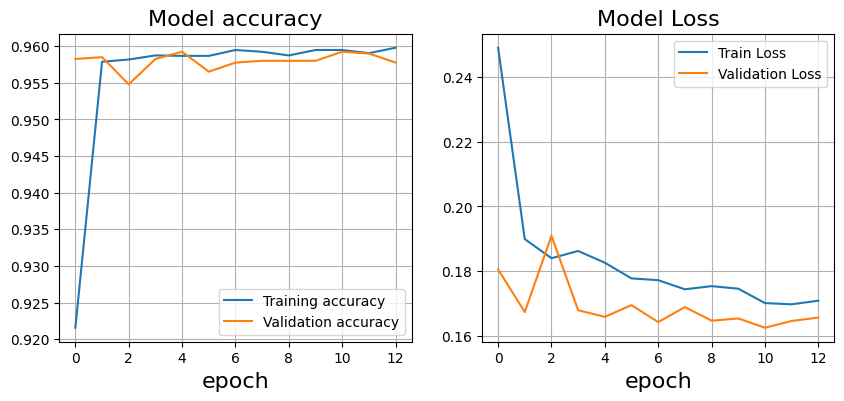

In [27]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")
plt.title('Model accuracy', fontsize=16)
plt.xlabel('epoch', fontsize=16)
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=16)
plt.xlabel('epoch', fontsize=16)
plt.grid(True)
plt.legend()
plt.show()


159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


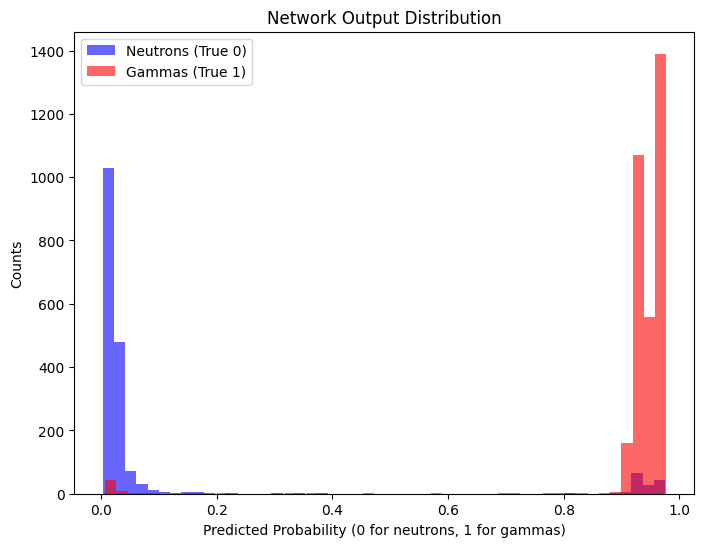

In [28]:
preds = model2.predict(data_test).flatten()

plt.figure(figsize=(8,6))

plt.hist(preds[labels_test == 0], bins=50, alpha=0.6, color='blue', label='Neutrons (True 0)')
plt.hist(preds[labels_test == 1], bins=50, alpha=0.6, color='red', label='Gammas (True 1)')

plt.title("Network Output Distribution")
plt.xlabel("Predicted Probability (0 for neutrons, 1 for gammas)")
plt.ylabel("Counts")
plt.legend()
plt.show()

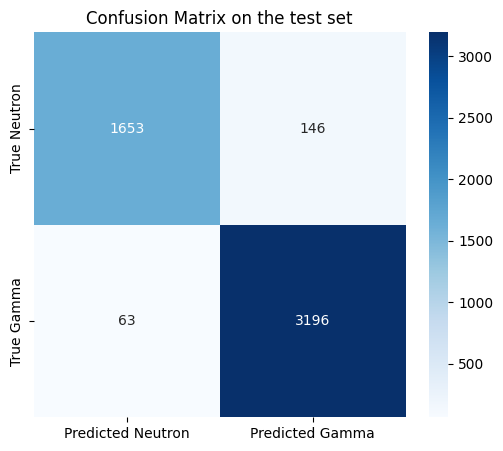

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds_binary = (preds > 0.5).astype(int)

cm = confusion_matrix(labels_test, preds_binary)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Neutron', 'Predicted Gamma'],
            yticklabels=['True Neutron', 'True Gamma'])
plt.title("Confusion Matrix on the test set")
plt.show()

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

prec = precision_score(labels_test, preds_binary)
recall = recall_score(labels_test, preds_binary)
f1 = f1_score(labels_test, preds_binary)
auc = roc_auc_score(labels_test, preds)

print("Precision:", prec)
print("Recall:", recall)
print("F1 score:", f1)
print(f"Area under the ROC curve (AUC): {auc:.4f}")

Precision: 0.9563135846798324
Recall: 0.9806689168456582
F1 score: 0.9683381305862748
Area under the ROC curve (AUC): 0.9573


Increasing the complexity of the neural network provided no significant performance benefits. All evaluation metrics are practically identical, and any slight differences are indistinguishable from underlying statistical fluctuations.

A closer inspection of the confusion matrix and the output probability distribution reveals two well-separated peaks, demonstrating that the model is highly confident in its predictions. In fact, the wrong classifications are made with near-certainty.
This high-confidence error rate implies that the problem is not the model architecture itself, but the presence of noisy or inaccurate ground-truth labels.
Therefore, the next step involves improving the intrinsic quality of the dataset, in order to reduce the errors on labels' assigments. Stricter cuts will be applied to the Time of Flight measurements to minimize label ambiguity and ensure that only signals with definitive particle identities are fed into the network.

## **Improving the dataset**

To improve the accuracy of the labels, more precise cuts are applied to the Time of Flight measurements.

The TOF peak corresponding to **photons** is fitted with a Gaussian function. The data selection is then restricted to events falling strictly within an window spanning from $\mu - 3\sigma$ to $\mu + 3\sigma$.  
Modeling the **neutron** Time of Flight (ToF) distribution requires a different mathematical approach compared to photons. Because neutrons possess varying kinetic energies, slower particles arrive at the detector with a delay, creating a long tail on the right side of the ToF spectrum. To correctly capture this shape, an asymmetric Gaussian distribution is utilized. Asymmetric cuts are then applied (from $\mu - 0.2\sigma$ to $\mu + 1\sigma$), ensuring maximum dataset purity by strictly isolating the left boundary from the photon region.

By isolating the two peaks, the risk of mislabeling is minimized, resulting in a significantly cleaner dataset for the training phase.

Fit parameters:
Mean (mu) = 0.084 ns
Standard Dev. (sigma) = 0.890 ns


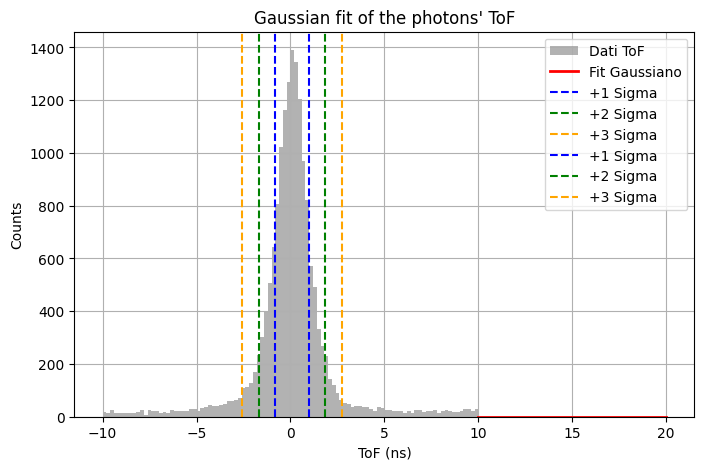

In [36]:
tof = data_raw[:,1]
def gaussiana(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

counts, bin_edges = np.histogram(tof, bins=100, range=(-10, 10))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#initial params
A_guess = np.max(counts) #amplitude
mu_guess = bin_centers[np.argmax(counts)] # x-position of the peak
sigma_guess = 1.0 # sigma
p0 = [A_guess, mu_guess, sigma_guess]

popt, pcov = curve_fit(gaussiana, bin_centers, counts, p0=p0)

A_opt, mu_opt, sigma_opt = popt
sigma_opt = abs(sigma_opt) #sigma needs to be positive

print(f"Fit parameters:")
print(f"Mean (mu) = {mu_opt:.3f} ns")
print(f"Standard Dev. (sigma) = {sigma_opt:.3f} ns")

#plot how the cuts for different sigmas would be
plt.figure(figsize=(8, 5))
plt.hist(tof, bins=100, range=(-10, 10), alpha=0.6, label='Dati ToF', color='gray')

x_fit = np.linspace(10, 20, 1000)
plt.plot(x_fit, gaussiana(x_fit, *popt), 'r-', linewidth=2, label='Fit Gaussiano')

plt.axvline(mu_opt + sigma_opt, color='blue', linestyle='--', label='+1 Sigma')
plt.axvline(mu_opt + 2*sigma_opt, color='green', linestyle='--', label='+2 Sigma')
plt.axvline(mu_opt + 3*sigma_opt, color='orange', linestyle='--', label='+3 Sigma')
plt.axvline(mu_opt - sigma_opt, color='blue', linestyle='--', label='+1 Sigma')
plt.axvline(mu_opt - 2*sigma_opt, color='green', linestyle='--', label='+2 Sigma')
plt.axvline(mu_opt - 3*sigma_opt, color='orange', linestyle='--', label='+3 Sigma')

plt.title("Gaussian fit of the photons' ToF")
plt.xlabel("ToF (ns)")
plt.ylabel("Counts")
plt.legend()
plt.grid(True)
plt.show()


Fit:
Mean (mu) = 11.809 ns
Standard Dev. (sigma) = 4.285 ns


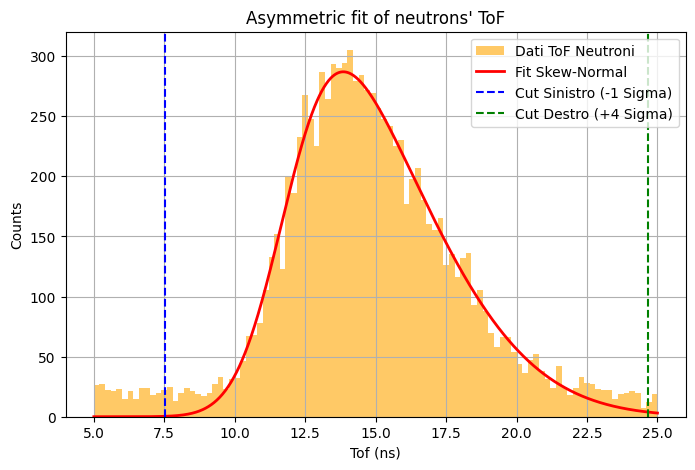

In [37]:
from scipy.special import erf

def skew_gaussiana(x, A, mu, sigma, alpha):
    #gaussian
    gauss = np.exp(-(x - mu)**2 / (2 * sigma**2))
    # the tail on the right (alpha > 0)
    skew = 1 + erf(alpha * (x - mu) / (sigma * np.sqrt(2)))
    return A * gauss * skew

counts, bin_edges = np.histogram(tof, bins=100, range=(5, 25))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

A_guess = np.max(counts)
mu_guess = bin_centers[np.argmax(counts)]
sigma_guess = 2.0
alpha_guess = 2.0

p0 = [A_guess, mu_guess, sigma_guess, alpha_guess]

popt, pcov = curve_fit(skew_gaussiana, bin_centers, counts, p0=p0)
A_opt_2, mu_opt_2, sigma_opt_2, alpha_opt = popt
sigma_opt_2 = abs(sigma_opt_2)

print("Fit:")
print(f"Mean (mu) = {mu_opt_2:.3f} ns")
print(f"Standard Dev. (sigma) = {sigma_opt_2:.3f} ns")
#print(f"Asimmetria (alpha) = {alpha_opt:.3f}")

plt.figure(figsize=(8, 5))
plt.hist(tof, bins=100, range=(5, 25), alpha=0.6, label='Dati ToF Neutroni', color='orange')

x_fit = np.linspace(5, 25, 1000)
plt.plot(x_fit, skew_gaussiana(x_fit, *popt), 'r-', linewidth=2, label='Fit Skew-Normal')

plt.axvline(mu_opt_2 - 1*sigma_opt_2, color='blue', linestyle='--', label='Cut Sinistro (-1 Sigma)')
plt.axvline(mu_opt_2 + 3*sigma_opt_2, color='green', linestyle='--', label='Cut Destro (+4 Sigma)')

plt.title("Asymmetric fit of neutrons' ToF")
plt.xlabel("Tof (ns)")
plt.ylabel("Counts")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
tof_min_photons = mu_opt - 3*sigma_opt
tof_max_photons = mu_opt + 3*sigma_opt

print(tof_min_photons)
print(tof_max_photons)

tof_min_neutrons = mu_opt_2 - 0.2*sigma_opt_2
tof_max_neutrons = mu_opt_2 + 1*sigma_opt_2

print(tof_min_neutrons)
print(tof_max_neutrons)

photons_data = data_raw[(tof >= tof_min_photons) & (tof <= tof_max_photons)]
neutrons_data = data_raw[(tof >= tof_min_neutrons) & (tof <= tof_max_neutrons)]

photons_pulses = photons_data[:, 2:]
neutrons_pulses = neutrons_data[:, 2:]

print('Gammas: ', photons_pulses.shape)
print('Neutrons: ', neutrons_pulses.shape)


-2.5857314230043422
2.7544854678070236
10.95166598421505
16.093114188283366
Gammas:  (14876, 512)
Neutrons:  (6021, 512)


In [39]:
data = np.vstack((photons_pulses, neutrons_pulses))
labels = np.zeros(len(data), dtype=int) #assegna come default 0 a tutti (quindi neutrone)
labels[:len(photons_pulses)] = 1 # forzo il valore 1 (quindi fotone ai 16108 fotoni)

# 0 = neutroni
# 1 = fotoni

data = data / (-data.min(axis=1, keepdims=True)) #normalization

data = np.reshape(data, (-1, data.shape[1], 1)) #reshape

print('Data: ', data.shape)

np.random.seed(42)
shuffle_indices = np.arange(0, len(data), dtype=int)
np.random.shuffle(shuffle_indices)
data = data[shuffle_indices]
labels = labels[shuffle_indices]

Data:  (20897, 512, 1)


In [40]:
from sklearn.model_selection import train_test_split

data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.2, random_state=42)

data_train, data_val, labels_train, labels_val = train_test_split(data_train, labels_train, test_size=0.2, random_state=42)

The third network has the same baseline architecture as the first one, with the key difference that it is now trained using the cleaner dataset.

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, Dropout

model3 = Sequential()

model3.add(Input(shape=(512, 1)))
model3.add(Conv1D(16, kernel_size=5, padding="same", activation='relu'))
model3.add(MaxPooling1D(2))
model3.add(Flatten())
model3.add(Dense(1, activation='sigmoid'))

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 512, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 256, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,193 (16.38 KB)

 Trainable params: 4,193 (16.38 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
%%time
import tensorflow as tf
from tensorflow import keras

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose = 2, restore_best_weights=True)

history = model3.fit(data_train, labels_train,
                    validation_data=(data_val, labels_val),
                    epochs=13,
                    batch_size=64,
                    callbacks = callbacks)

Epoch 1/13
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8231 - loss: 0.4058 - val_accuracy: 0.9719 - val_loss: 0.1854
Epoch 2/13
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9759 - loss: 0.1405 - val_accuracy: 0.9761 - val_loss: 0.1288
Epoch 3/13
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9773 - loss: 0.1208 - val_accuracy: 0.9770 - val_loss: 0.1236
Epoch 4/13
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9778 - loss: 0.1175 - val_accuracy: 0.9758 - val_loss: 0.1271
Epoch 5/13
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9779 - loss: 0.1164 - val_accuracy: 0.9758 - val_loss: 0.1242
Epoch 6/13
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9777 - loss: 0.1165 - val_accuracy: 0.9758 - val_loss: 0.1218
Epoch 7/13
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9781 - loss: 0.1143 - val_accuracy: 0.9758 - val_loss: 0.1236
Epoch 8/13
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9779 - loss: 0.1144 - val_accuracy: 0.

In [43]:
test_loss_3, test_accuracy_3 = model3.evaluate(data_test, labels_test, verbose=1)
print('Test loss: ', test_loss_3)
print('Test accuracy: ', test_accuracy_3 * 100, '%')

131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9813 - loss: 0.0935
Test loss:  0.09348773211240768
Test accuracy:  98.1339693069458 %


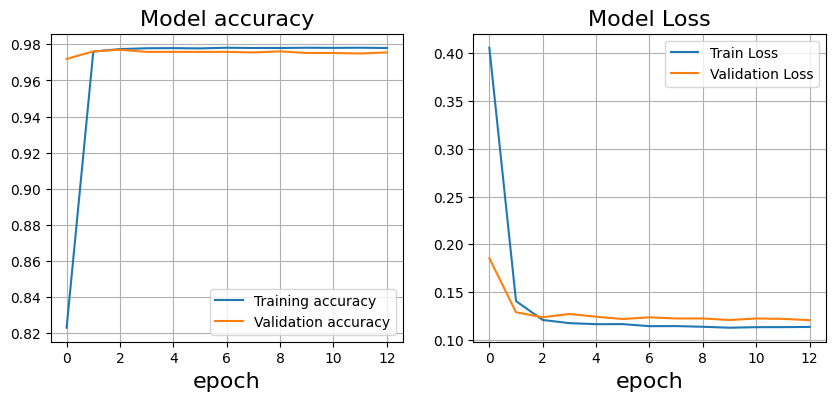

In [44]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")
plt.title('Model accuracy', fontsize=16)
plt.xlabel('epoch', fontsize=16)
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=16)
plt.xlabel('epoch', fontsize=16)
plt.grid(True)
plt.legend()
plt.show()

131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


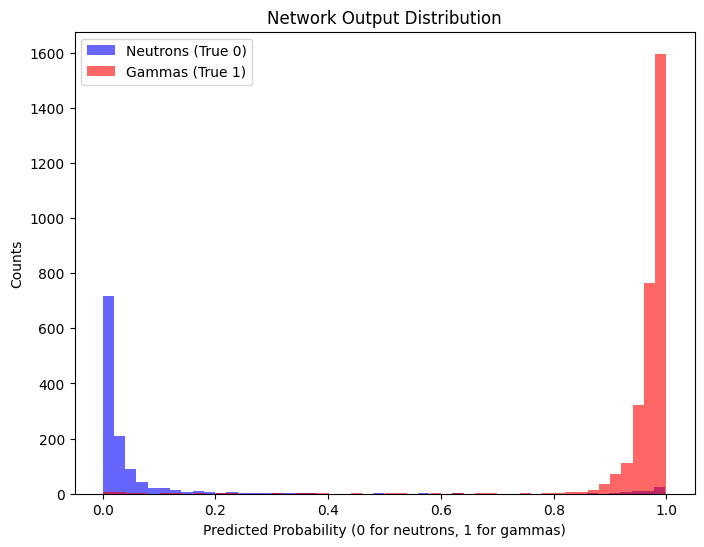

In [45]:
preds = model3.predict(data_test).flatten()

plt.figure(figsize=(8,6))

plt.hist(preds[labels_test == 0], bins=50, alpha=0.6, color='blue', label='Neutrons (True 0)')
plt.hist(preds[labels_test == 1], bins=50, alpha=0.6, color='red', label='Gammas (True 1)')

plt.title("Network Output Distribution")
plt.xlabel("Predicted Probability (0 for neutrons, 1 for gammas)")
plt.ylabel("Counts")
plt.legend()
plt.show()

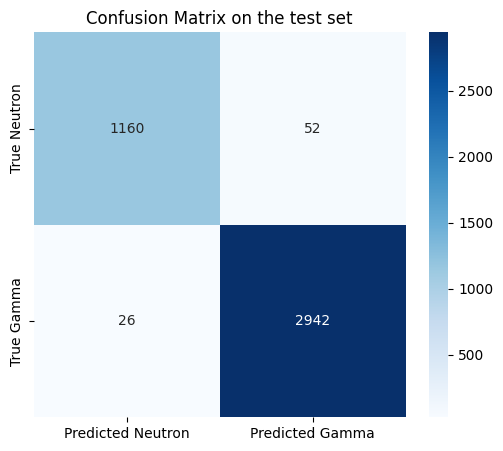

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds_binary = (preds > 0.5).astype(int)

cm = confusion_matrix(labels_test, preds_binary)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Neutron', 'Predicted Gamma'],
            yticklabels=['True Neutron', 'True Gamma'])
plt.title("Confusion Matrix on the test set")
plt.show()

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

prec = precision_score(labels_test, preds_binary)
recall = recall_score(labels_test, preds_binary)
f1 = f1_score(labels_test, preds_binary)
auc = roc_auc_score(labels_test, preds)

print("Precision:", prec)
print("Recall:", recall)
print("F1 score:", f1)
print(f"Area under the ROC curve (AUC): {auc:.4f}")

Precision: 0.9826319305277221
Recall: 0.9912398921832885
F1 score: 0.9869171418986917
Area under the ROC curve (AUC): 0.9798


This model achieved a test accuracy and an AUC of ~**98%**, representing a significant and undeniable improvement over the previous results. This outcome clearly demonstrates that enhancing the quality of the dataset, rather than arbitrarily scaling the complexity of the neural network, is the most effective strategy for boosting the model's overall performance. By removing ambiguous signals through stricter ToF cuts, we provided the algorithm with a much clearer ground truth, proving that a simple, lightweight architecture is more than sufficient for this classification task when supported by high quality data.

## **RandomForestClassifier**

Deep Learning architectures, such as CNNs, are extremely powerful but often computationally demanding and overly complex for straightforward classification tasks. An effective alternative is to approach this binary classification using different traditional ML algorithms. The Random Forest was selected, because it provides a simpler, faster, and highly stable model naturally resistant to overfitting. This model is trained on the purified dataset, since it was demonstrated that it delivers significantly better performance. However, before proceeding with the training, the shape of the input data must be adjusted to match the mathematical requirements of the algorithm.

In [48]:
data.shape

(20897, 512, 1)

In [49]:
labels.shape

(20897,)

In [50]:
data_rf = data.reshape(data.shape[0], -1)
print(f"{data_rf.shape}")

labels_rf = labels

(20897, 512)


In [51]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, cross_val_predict

data_rf_train, data_rf_test, labels_rf_train, labels_rf_test = train_test_split(data_rf,
                                                                                labels_rf,
                                                                                test_size=0.2,
                                                                                random_state=1234)
rfc_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
val_scores = cross_val_score(rfc_clf, data_rf_train, labels_rf_train, cv = 3, scoring = "accuracy")

CPU times: user 3min 7s, sys: 383 ms, total: 3min 8s
Wall time: 25.4 s


To ensure the reliability of the Random Forest classifier (`rfc_clf`) and verify its ability to generalize, a 3-Fold Cross-Validation is applied to the training set (`data_rf_train` and `labels_rf_train`) prior to the final evaluation. The model is configured with 100 trees and restricted to a max_depth of 20 to prevent early overfitting.  

In [52]:
print(f"Accuracy: {val_scores}")
print(f"Mean Accuracy: {val_scores.mean()}")

Accuracy: [0.97774987 0.9804379  0.97684853]
Mean Accuracy: 0.9783454325277924


In [53]:
labels_rf_pred = cross_val_predict(rfc_clf, data_rf_train, labels_rf_train, cv = 3)
print(f"{labels_rf_pred.shape}")

labels_rf_scores = cross_val_predict(rfc_clf, data_rf_train, labels_rf_train, cv=3, method="predict_proba") #probabilities for each of the two possible classes
scores_photons = labels_rf_scores[:, 1]

(16717,)


In [62]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

matrix = confusion_matrix(labels_rf_train, labels_rf_pred)
prec = precision_score(labels_rf_train, labels_rf_pred)
recall = recall_score(labels_rf_train, labels_rf_pred)
f1 = f1_score(labels_rf_train, labels_rf_pred)
auc = roc_auc_score(labels_rf_train, scores_photons)


print("Confusion matrix:", confusion_matrix(labels_rf_train, labels_rf_pred))
print("Precision:", prec)
print("Recall:", recall)
print("F1 score:", f1)
print(f"Area under the ROC curve (AUC): {auc:.4f}")

Confusion matrix: [[ 4515   267]
 [   95 11840]]
Precision: 0.9779466424382589
Recall: 0.9920402178466695
F1 score: 0.9849430163879876
Area under the ROC curve (AUC): 0.9729


To finalize the Random Forest classifier, a global training is executed on the entire training set. The final, definitive metrics will be extracted exclusively from the independent test set (`data_rf_test`).

In [55]:
%%time
rfc_clf.fit(data_rf_train, labels_rf_train)

CPU times: user 1min 45s, sys: 134 ms, total: 1min 45s
Wall time: 13.8 s


RandomForestClassifier(max_depth=20, n_jobs=-1, random_state=42)

Test Accuracy: 0.9746411483253589
Precision: 0.9751927589674824
Recall: 0.9891193471608296
F1 score: 0.9821066846725186


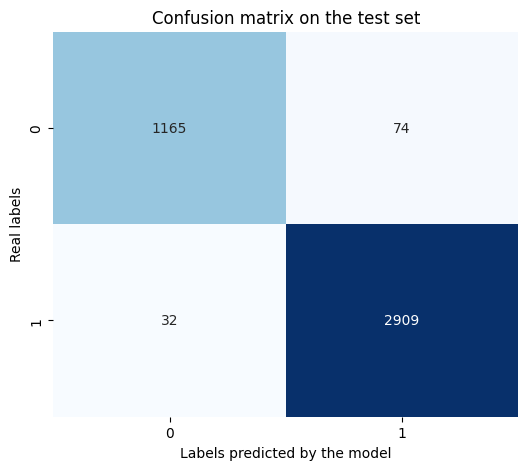

In [64]:
labels_rf_test_pred = rfc_clf.predict(data_rf_test)

test_accuracy = accuracy_score(labels_rf_test, labels_rf_test_pred)
matrix_test = confusion_matrix(labels_rf_test, labels_rf_test_pred)
prec_test = precision_score(labels_rf_test, labels_rf_test_pred)
recall_test = recall_score(labels_rf_test, labels_rf_test_pred)
f1_test = f1_score(labels_rf_test, labels_rf_test_pred)

print("Test Accuracy:", test_accuracy)
print("Precision:", prec_test)
print("Recall:", recall_test)
print("F1 score:", f1_test)

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_test, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion matrix on the test set")
plt.xlabel("Labels predicted by the model")
plt.ylabel("Real labels")
plt.show()

In [57]:
labels_rf_scores_test = cross_val_predict(rfc_clf, data_rf_test, labels_rf_test, cv=3, method="predict_proba") #probabilities for each of the two possible classes
labels_rf_scores_test.shape

(4180, 2)

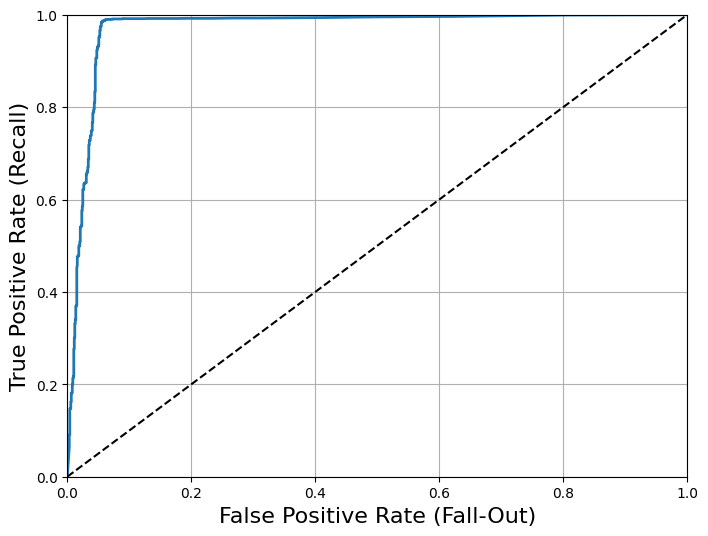

Area under the ROC curve (AUC): 0.9722


In [58]:
from sklearn.metrics import roc_curve

scores_photons_test = labels_rf_scores_test[:, 1]
fpr2, tpr2, thresholds2 = roc_curve(labels_rf_test, scores_photons_test)

def plot_roc_curve(fpr2, tpr2, label=None):
    plt.plot(fpr2, tpr2, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) #segnale assegnato a fotoni ma che in realtà era di neutroni
    plt.ylabel('True Positive Rate (Recall)', fontsize=16) #segnale che è assegnato a fotoni ed era effettivamente di fotoni
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr2, tpr2)
plt.show()

auc2 = roc_auc_score(labels_rf_test, scores_photons_test)
print(f"Area under the ROC curve (AUC): {auc2:.4f}")

This comparative study successfully demonstrates that dataset purification is the primary driving factor for accurate Pulse Shape Discrimination. Results show that optimizing the ToF cuts elevated the accuracy of a simple CNN from 95% to 98%, rendering deeper and more complex architectures unnecessary.
Moreover, benchmarking these results against a Random Forest classifier revealed that traditional Machine Learning remains a highly viable solution for this physics application, because it provides a performance level nearly as Deep Learning, while offering significant advantages in terms of computational speed and model transparency.  
In conclusion, investing resources in raw data quality yields superior discrimination capabilities, allowing both neural networks and simpler ensemble algorithms to achieve near-optimal results. A final comparison of the Accuracy, F1-Score, and ROC AUC for the four implemented models is presented in the table below. The displayed percentages represent expected performance ranges, as slight variations are to be expected due to the randomness intrinsically tied to the model training and data splitting processes.

| Classifier | Accuracy (%) | F1-Score (%) | AUC (%) |
|---|---|---|---|
| Simple CNN | 95.8 | 96.8 | 95.6 |
| Complex CNN | 95.8 | 96.8 | 95.7 |
| Simple CNN with improved dataset | 98.1 | 98.7 | 97.9 |
| RandomForestClassifier | 97.5 | 98.2 | 97.2 |